In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_excel("Raisin_Dataset.xlsx")

In [ ]:
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [ ]:
df.tail()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
895,83248,430.077308,247.838695,0.817263,85839,0.668793,1129.072,Besni
896,87350,440.735698,259.293149,0.808629,90899,0.636476,1214.252,Besni
897,99657,431.706981,298.837323,0.721684,106264,0.741099,1292.828,Besni
898,93523,476.344094,254.176054,0.845739,97653,0.658798,1258.548,Besni
899,85609,512.081774,215.271976,0.907345,89197,0.632020,1272.862,Besni


In [ ]:
df.isnull().sum()

,0
Area,0
MajorAxisLength,0
MinorAxisLength,0
Eccentricity,0
ConvexArea,0
Extent,0
Perimeter,0
Class,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Class"].unique()

array(['Kecimen', 'Besni'], dtype=object)

In [ ]:
df["Class"].unique()

array(['Kecimen', 'Besni'], dtype=object)

In [ ]:
df["Class"].value_counts()

,count
Class,
Kecimen,450
Besni,450


## Bar-Plot

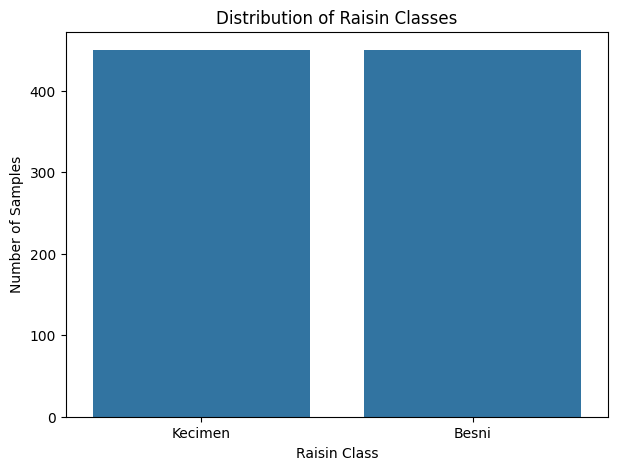

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(data = df, x = "Class")

plt.title("Distribution of Raisin Classes")
plt.xlabel("Raisin Class")
plt.ylabel("Number of Samples")

plt.show()

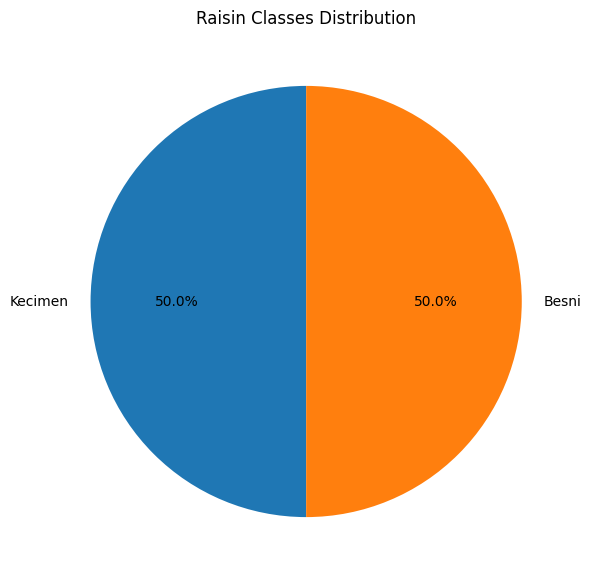

In [ ]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Raisin Classes Distribution")

plt.show()

In [ ]:
numerical_features = df.select_dtypes(include = np.number).columns

print("Numerical Features:")
print(numerical_features.tolist())

Numerical Features:
['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']


## Histograms

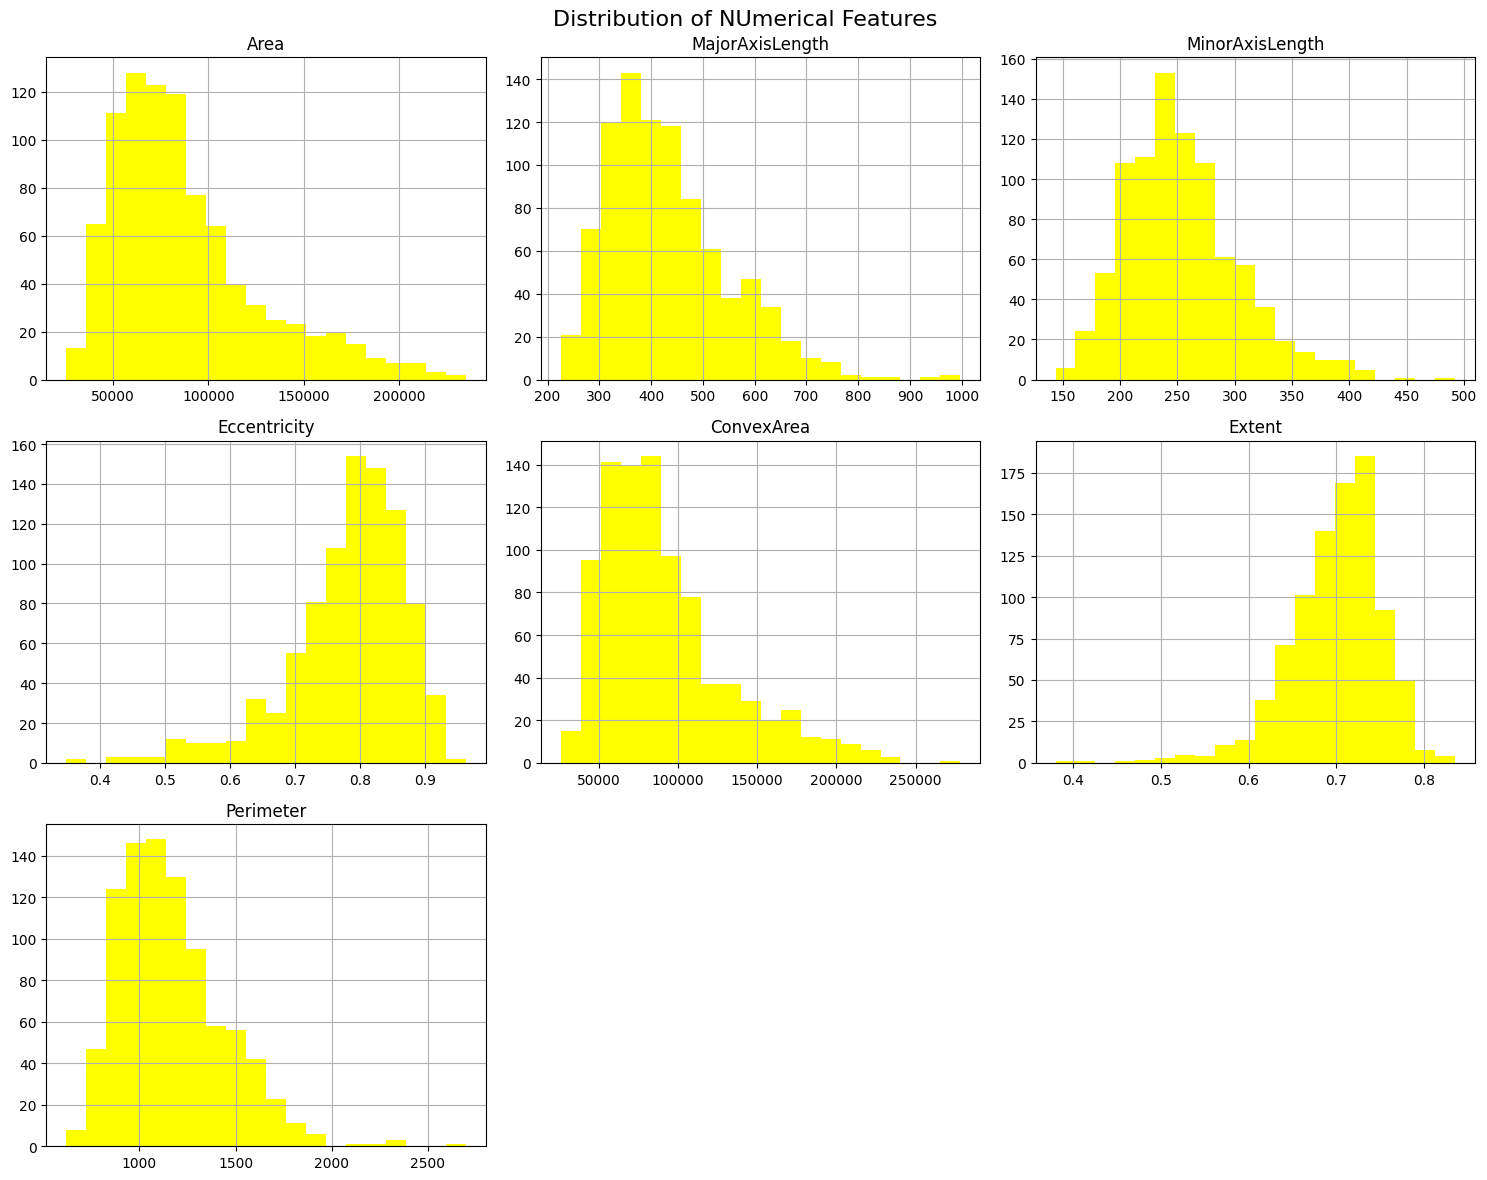

In [ ]:
df[numerical_features].hist(figsize=(15, 12), bins=20, color='yellow')
plt.suptitle("Distribution of NUmerical Features",fontsize = 16,)

plt.tight_layout()
plt.show()

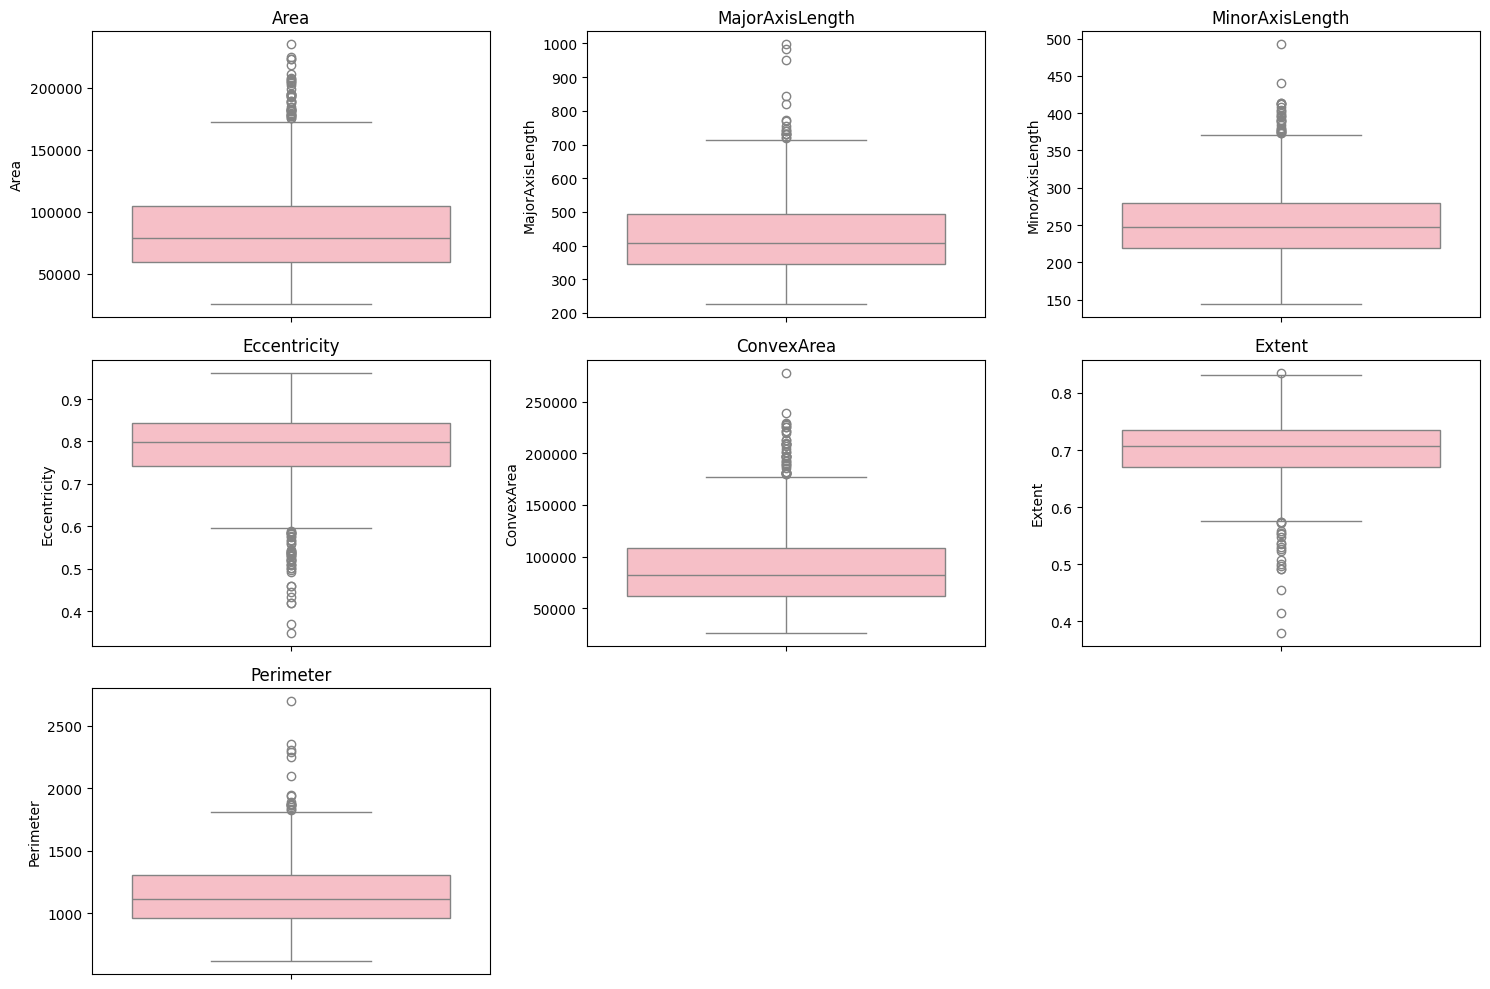

In [ ]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='lightpink')
    plt.title(col)

plt.tight_layout()
plt.show()

## Histograms with kde functions

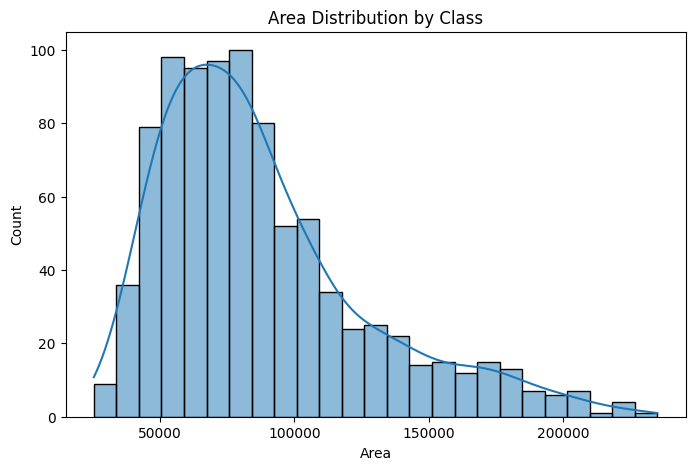

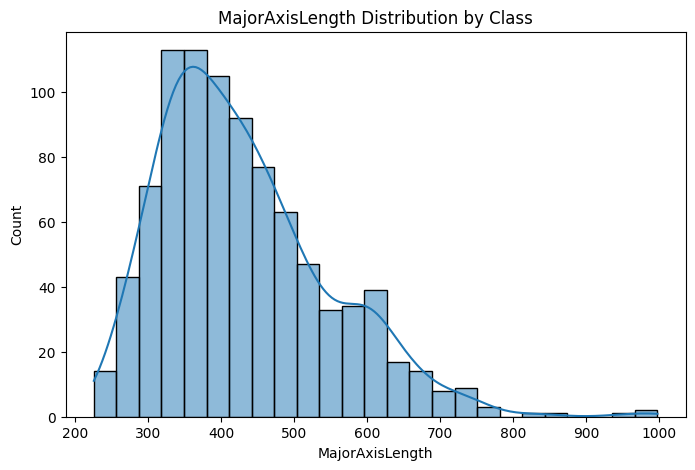

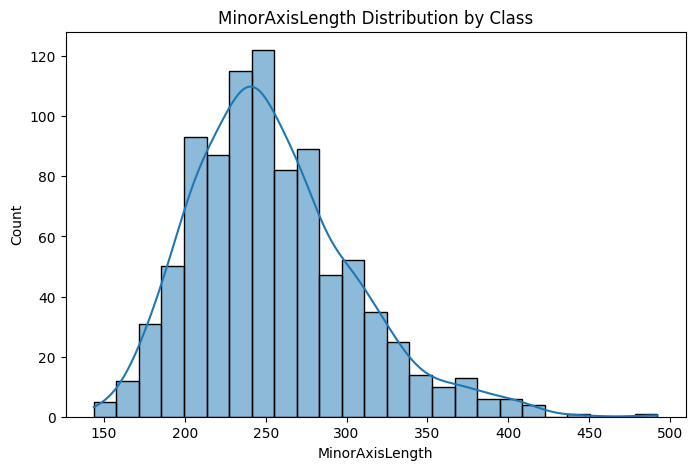

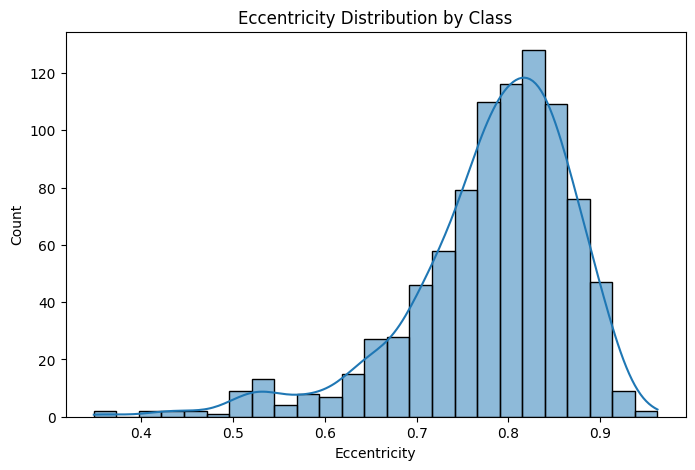

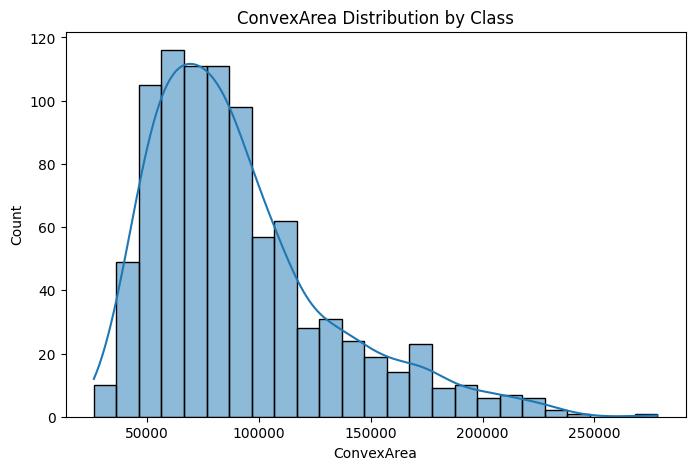

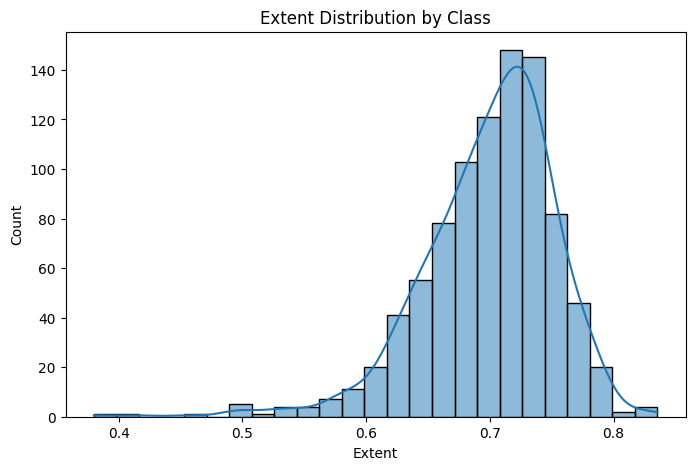

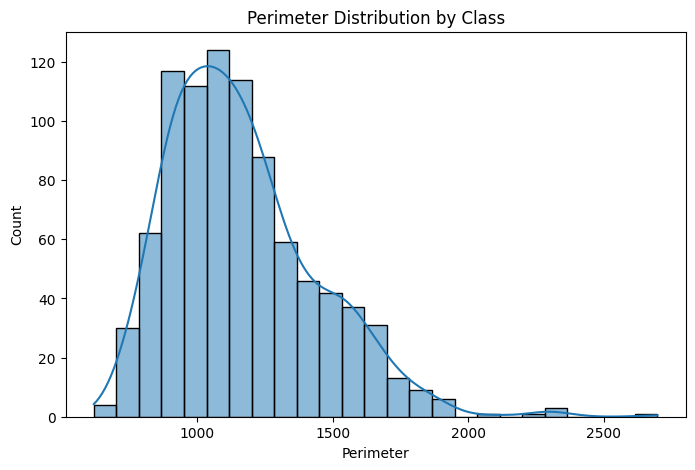

In [ ]:
for columns in numerical_features:

  plt.figure(figsize=(8, 5))

  sns.histplot(data = df, x = columns, kde = True, bins = 25)

  plt.title(f"{columns} Distribution by Class")

  plt.show()

## Correlation Matrix

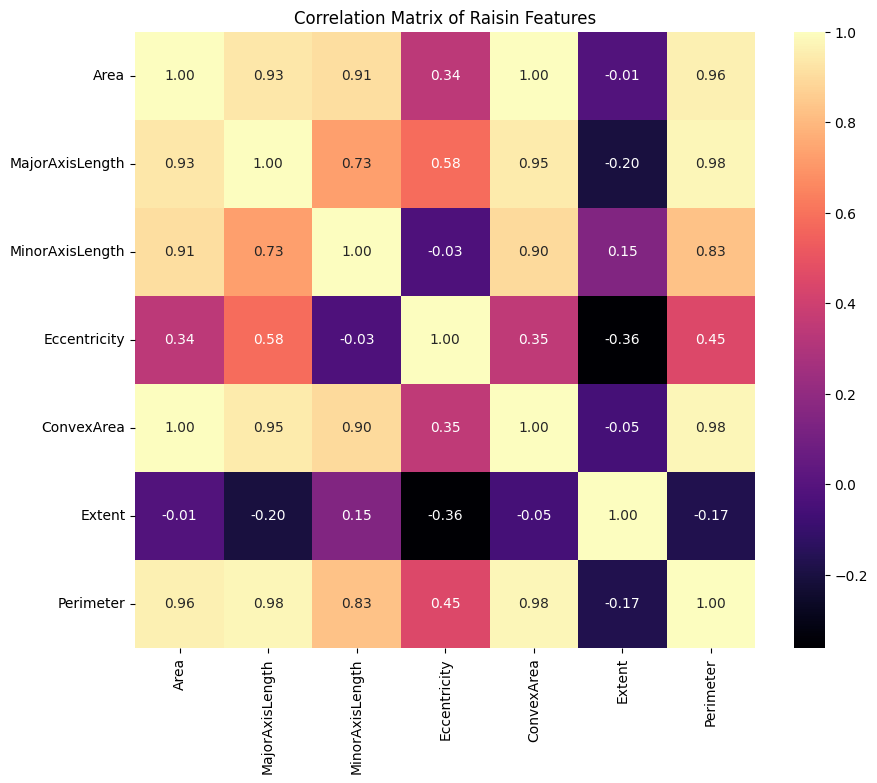

In [ ]:
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='magma', fmt=".2f")
plt.title("Correlation Matrix of Raisin Features")
plt.show()

## Scatter-Plot

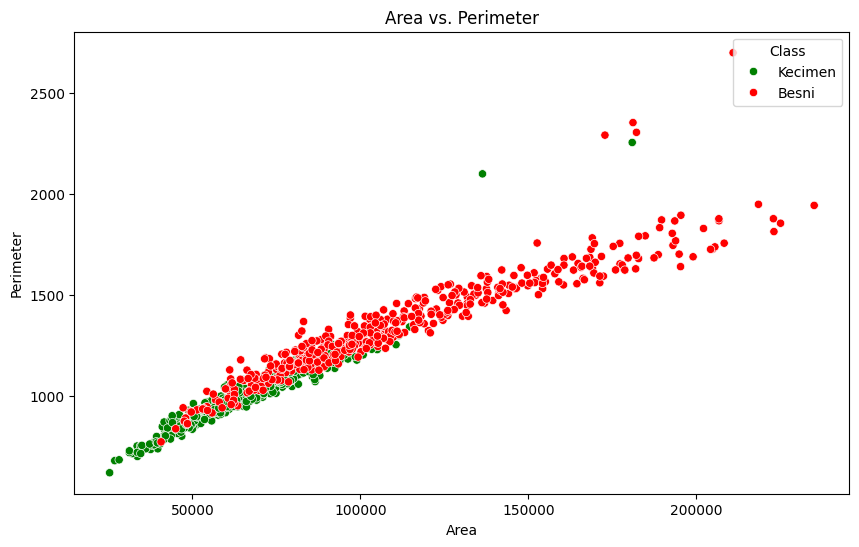

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='Area', y='Perimeter', hue='Class', palette={'Kecimen': 'Green', 'Besni': 'Red'})
plt.title('Area vs. Perimeter')
plt.xlabel('Area')
plt.ylabel('Perimeter')
plt.show()

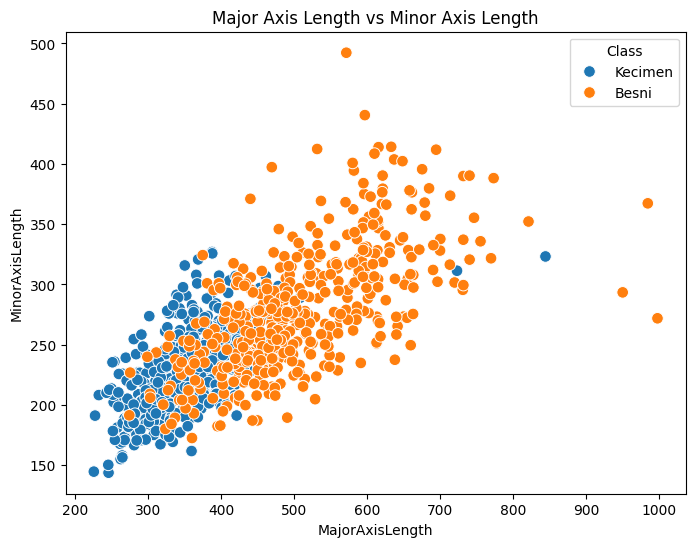

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x='MajorAxisLength', y='MinorAxisLength', hue='Class', s=70)
plt.title("Major Axis Length vs Minor Axis Length")
plt.show()

In [ ]:
label_encoder = LabelEncoder()
df['Class_encoded'] = label_encoder.fit_transform(df['Class'])

print(df[["Class", "Class_encoded"]].head(10))

     Class  Class_encoded
0  Kecimen              1
1  Kecimen              1
2  Kecimen              1
3  Kecimen              1
4  Kecimen              1
5  Kecimen              1
6  Kecimen              1
7  Kecimen              1
8  Kecimen              1
9  Kecimen              1


In [ ]:
print("Class mapping:")

for index, class_name in enumerate(label_encoder.classes_):
  print(index, "=", class_name)

Class mapping:
0 = Besni
1 = Kecimen


In [ ]:
X = df[numerical_features]

y = df["Class_encoded"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (900, 7)
y shape: (900,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Training samples:", X_test.shape[0])


Training samples: 720
Training samples: 180


In [ ]:
GaussianNB()

GaussianNB()

In [ ]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred = gnb.predict(X_test)
print("Predicted label:")
print(y_pred)

Predicted label:
[0 1 1 0 1 1 1 1 1 1 0 0 0 1 0 0 0 1 1 0 1 0 1 1 0 1 1 0 0 0 1 0 0 0 0 0 1
 0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 0 0 1 1
 0 0 1 1 1 0 0 1 0 1 0 0 1 1 1 0 1 1 0 0 0 1 1 1 0 0 0 1 0 1 1 1 0 1 1 1 0
 0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 0 0 0 1 1 1 0 0 0 1 1 1 0 1 0 1 0 1
 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 0 0 0 0 1 1]


In [ ]:
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
print(comparison.head(5))

   Actual  Predicted
0       1          0
1       0          1
2       1          1
3       0          0
4       1          1


In [ ]:
comparison["Actual_Class"] = label_encoder.inverse_transform(comparison["Actual"])

comparison["Predicted_Class"] = label_encoder.inverse_transform(comparison["Predicted"])

comparison.head(5)

,Actual,Predicted,Actual_Class,Predicted_Class
0,1,0,Kecimen,Besni
1,0,1,Besni,Kecimen
2,1,1,Kecimen,Kecimen
3,0,0,Besni,Besni
4,1,1,Kecimen,Kecimen


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8277777777777777
Accuracy (%): 82.77777777777777


In [ ]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.7889908256880734


In [ ]:
recall = recall_score(y_test, y_pred,)
print("Recall:", recall)

Recall: 0.9148936170212766


In [ ]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.8472906403940886


In [ ]:
print(" ==== MODEL PERFORMANCE ====")
print(f"Accuracy {accuracy:.4f}")
print(f"Precision {precision:.4f}")
print(f"Recall {recall:.4f}")
print(f"F1 Score {f1:.4f}")

 ==== MODEL PERFORMANCE ====
Accuracy 0.8278
Precision 0.7890
Recall 0.9149
F1 Score 0.8473


In [ ]:
print("Classification Report: \n")
print(classification_report(y_test, y_pred))

Classification Report: 

              precision    recall  f1-score   support

           0       0.89      0.73      0.80        86
           1       0.79      0.91      0.85        94

    accuracy                           0.83       180
   macro avg       0.84      0.82      0.82       180
weighted avg       0.84      0.83      0.83       180



In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[63 23]
 [ 8 86]]


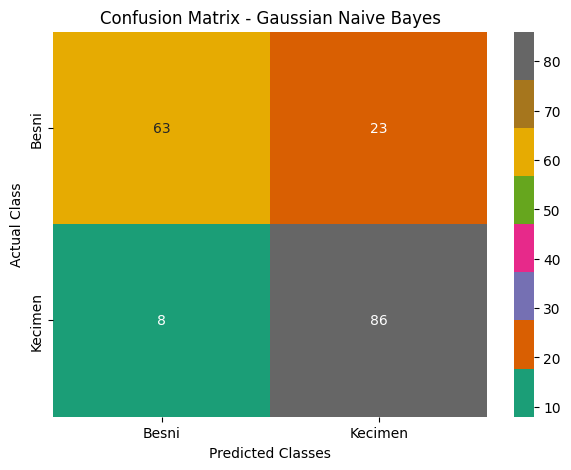

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Dark2', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Classes')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix - Gaussian Naive Bayes')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

y_train_pred = gnb.predict(X_train)
y_test_pred = gnb.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8222222222222222
Testing Accuracy: 0.8277777777777777


## Main_Hyperparameters

In [ ]:
GaussianNB(var_smoothing = 1e-9)

GaussianNB()

In [ ]:
print(gnb.get_params())

{'priors': None, 'var_smoothing': 1e-09}


In [ ]:
smoothing_values = [1e-12, 1e-10, 1e-9, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]

results= []

for value in smoothing_values:

  model = GaussianNB(var_smoothing = value)

  model.fit(X_train, y_train)

  prediction = model.predict(X_test)

  acc = accuracy_score(y_test, prediction)
  prec = precision_score(y_test, prediction)
  rec = recall_score(y_test, prediction)

  f1_value = f1_score(y_test, prediction)
  results.append([value, acc, prec, rec, f1_value])

In [ ]:
results_df = pd.DataFrame(results, columns = ["var_smoothing", "Accuracy", "Precision", "Recall", "F1_Score"])

results_df

,var_smoothing,Accuracy,Precision,Recall,F1_Score
0,1.000000e-12,0.827778,0.788991,0.914894,0.847291
1,1.000000e-10,0.827778,0.788991,0.914894,0.847291
2,1.000000e-09,0.827778,0.788991,0.914894,0.847291
3,1.000000e-07,0.827778,0.788991,0.914894,0.847291
4,1.000000e-06,0.827778,0.788991,0.914894,0.847291
5,1.000000e-05,0.833333,0.790909,0.925532,0.852941
6,1.000000e-04,0.827778,0.783784,0.925532,0.848780
7,1.000000e-03,0.827778,0.783784,0.925532,0.848780
8,1.000000e-02,0.827778,0.783784,0.925532,0.848780


In [ ]:
area = float(input("Enter area:"))
major_axis = float(input("Enter major axis length: "))
minor_axis = float(input("Enter minor axis length: "))
eccentricity = float(input("Enter ecentricity:"))
convex_area = float(input("Enter convex area: "))
extent = float(input("Enter extent: "))
perimeter = float(input("Enter Perimeter: "))

new_sample = pd.DataFrame({'Area': [area], 'MajorAxisLength': [major_axis], 'MinorAxisLength': [minor_axis], 'Eccentricity': [eccentricity], 'ConvexArea': [convex_area], 'Extent': [extent], 'Perimeter': [perimeter]})

prediction = gnb.predict(new_sample)

predicted_class = label_encoder.inverse_transform(prediction)

print("\nPredicted Raisin Class:", predicted_class[0])


Enter area:91230
Enter major axis length: 458.12
Enter minor axis length: 258.91
Enter ecentricity:0.825
Enter convex area: 94512
Enter extent: 0.685
Enter Perimeter: 1215.40

Predicted Raisin Class: Besni
